# 01 — Data Collection

**7030DATSCI · Event-Driven Market Impact Modelling**  
**Author:** Ibrahim Haroun · **LJMU 2025–2026** · **Version:** 2.0 narrowed scope

---

## Purpose of this notebook

This notebook collects the raw datasets needed for a focused MSc-level project on whether political and macroeconomic events affect the S&P 500 and whether event information improves short-term prediction.

The project has been narrowed from a broad causal/market-microstructure design into a more realistic dissertation pipeline:

1. **Event study:** Do presidential communications and Federal Reserve announcements generate statistically significant abnormal returns in the S&P 500?
2. **Feature importance:** Which event-derived and macroeconomic features are most informative for next-day S&P 500 returns?
3. **Prediction:** Does adding event information improve prediction over a market-only baseline?

This notebook collects and validates only the datasets required for that story.

## Scope decisions

### Included in the main project

| Dataset | Keep? | Reason |
|---|---:|---|
| SPY daily OHLCV | Yes | Main proxy for S&P 500 returns and event-study outcome. |
| VIX | Yes | Market uncertainty control and volatility regime feature. |
| FRED macro indicators | Yes | Economic context: rates, inflation, unemployment, yield spread. |
| FOMC meeting dates | Yes | Clean, high-impact macro-policy event calendar. |
| Presidential communications | Yes | Main political communication/event text source. |

### Removed from the main pipeline

| Dataset | Decision | Reason |
|---|---|---|
| QQQ / GLD / TLT | Optional appendix only | Useful cross-asset checks, but not needed for the main S&P 500 research question. |
| GDELT | Removed | Very large collection burden and a different geopolitical-risk project. |
| Structural causal model | Removed from main RQs | Too large for one MSc dissertation unless supervisor specifically requires it. |

The notebook still leaves clear extension points if these are later needed for an appendix or future work.

---
## 0. Setup and dependencies

This cell imports the packages used in the data collection notebook. It also creates the project folders if they do not already exist.

In [1]:
# ── Optional dependency installer ───────────────────────────────────────────
# Keep this enabled in Colab / fresh environments. Comment it out if your local
# environment is already configured.
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = [
    "pandas", "numpy", "yfinance", "fredapi", "pyarrow", "fastparquet",
    "matplotlib", "certifi", "requests"
]

def ensure_package(package: str) -> None:
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

for package in REQUIRED_PACKAGES:
    ensure_package(package)

print("Dependency check complete.")

Dependency check complete.


In [2]:
# ── Imports ─────────────────────────────────────────────────────────────────
from pathlib import Path
from datetime import datetime
import os
import ssl
import json
import warnings

import certifi
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from fredapi import Fred

warnings.filterwarnings("ignore")

# SSL helper for macOS / some university networks
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["CURL_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

print("Imports loaded successfully.")

Imports loaded successfully.


---
## 1. Project configuration

The project uses one primary market target: **SPY**, an ETF commonly used as a liquid proxy for the S&P 500. The date range is set to 2015–2025 to cover Obama, Trump, Biden, and the start of the second Trump term while keeping the data manageable.

In [3]:
# ── Project paths ───────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RAW = DATA_DIR / "raw"
INTERIM = DATA_DIR / "interim"
FIGURES = PROJECT_ROOT / "reports" / "figures"

for folder in [RAW, INTERIM, FIGURES, RAW / "app_csv"]:
    folder.mkdir(parents=True, exist_ok=True)

# ── yfinance cache location ─────────────────────────────────────────────────
# yfinance keeps a small sqlite cache (ticker timezone/session info) in an
# OS-default cache directory. If that directory is missing or not writable,
# yf.download() fails with: OperationalError('unable to open database file').
# Pointing the cache at a writable, project-local folder avoids this.
YF_CACHE_DIR = PROJECT_ROOT / ".cache" / "yfinance"
YF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
try:
    yf.set_tz_cache_location(str(YF_CACHE_DIR))
except Exception as cache_error:
    print(f"Could not set yfinance cache location ({cache_error}); using its default cache.")

# ── Date range ──────────────────────────────────────────────────────────────
START_DATE = "2015-01-01"
END_DATE = "2025-12-31"

# ── Main market universe ────────────────────────────────────────────────────
TARGET_TICKER = "SPY"
OPTIONAL_TICKERS = ["QQQ", "GLD", "TLT"]  # not used in the main dissertation pipeline

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data path: {RAW}")
print(f"Period       : {START_DATE} → {END_DATE}")
print(f"Main ticker  : {TARGET_TICKER}")

Project root : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI
Raw data path: /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/data/raw
Period       : 2015-01-01 → 2025-12-31
Main ticker  : SPY


In [4]:
# ── Save helpers ────────────────────────────────────────────────────────────
def save_table(df: pd.DataFrame, path: Path, index: bool = True) -> Path:
    'Save a table to parquet, falling back to CSV if parquet engines fail.'
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        df.to_parquet(path, index=index)
        return path
    except Exception as parquet_error:
        csv_path = path.with_suffix(".csv")
        df.to_csv(csv_path, index=index)
        print(f"Parquet failed for {path.name}; saved CSV instead. Reason: {parquet_error}")
        return csv_path


def flatten_yfinance_columns(df: pd.DataFrame) -> pd.DataFrame:
    'Flatten yfinance MultiIndex columns if they appear.'
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    return df


def normalise_date_index(df: pd.DataFrame) -> pd.DataFrame:
    'Ensure a datetime index named date.'
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df.index.name = "date"
    return df.sort_index()

def load_if_cached(path: Path, force: bool = False):
    'Load a previously saved parquet/CSV table if it exists and is non-empty; otherwise return None.'
    # NOTE (2026-07-06 data-collection robustness fix): a cache file existing is not
    # sufficient evidence that it is usable -- a prior run whose yf.download()/API call
    # returned 0 rows (e.g. a transient network/rate-limit failure) still gets saved by
    # save_table(), and without this check that empty file would be trusted forever on
    # every future run (this is exactly what happened to spy_ohlcv.parquet/spy_returns.parquet).
    # Treating an empty cached table the same as a missing one makes the loader fall
    # through to a fresh download attempt instead of silently propagating the failure.
    path = Path(path)
    if force:
        return None
    if path.exists():
        cached = pd.read_parquet(path)
        if not cached.empty:
            return cached
        print(f"Cached file {path.name} exists but is empty (0 rows) -- ignoring stale cache and re-fetching.")
    csv_fallback = path.with_suffix(".csv")
    if csv_fallback.exists():
        cached = pd.read_csv(csv_fallback, index_col=0, parse_dates=True)
        if not cached.empty:
            return cached
        print(f"Cached file {csv_fallback.name} exists but is empty (0 rows) -- ignoring stale cache and re-fetching.")
    return None

---
## 2. Market data — SPY daily OHLCV

This section downloads daily OHLCV data for SPY. SPY is the main outcome series for the project.

The notebook saves:

- `spy_ohlcv.parquet` — raw OHLCV series
- `spy_returns.parquet` — daily return features used later for event windows and prediction

In [5]:
SPY_PATH = RAW / "spy_ohlcv.parquet"
FORCE_REFRESH_SPY = False  # set True to re-download from yfinance even if a cached file exists

spy_ohlcv = load_if_cached(SPY_PATH, force=FORCE_REFRESH_SPY)

if spy_ohlcv is not None:
    print(f"Loaded cached SPY OHLCV from {SPY_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(spy_ohlcv):,} rows). Set FORCE_REFRESH_SPY = True to re-download.")
else:
    spy_ohlcv = yf.download(
        TARGET_TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
    )

    spy_ohlcv = flatten_yfinance_columns(spy_ohlcv)
    spy_ohlcv = normalise_date_index(spy_ohlcv)
    spy_ohlcv.columns = [c.lower().replace(" ", "_") for c in spy_ohlcv.columns]

    # Keep a clean, predictable schema
    expected_cols = ["open", "high", "low", "close", "adj_close", "volume"]
    available_cols = [c for c in expected_cols if c in spy_ohlcv.columns]
    spy_ohlcv = spy_ohlcv[available_cols]

    save_table(spy_ohlcv, SPY_PATH)

    print(f"SPY OHLCV rows : {len(spy_ohlcv):,}")
    print(f"Date range     : {spy_ohlcv.index.min().date()} → {spy_ohlcv.index.max().date()}")
    print(f"Columns        : {list(spy_ohlcv.columns)}")

spy_ohlcv.head()

SPY OHLCV rows : 2,765
Date range     : 2015-01-02 → 2025-12-30
Columns        : ['open', 'high', 'low', 'close', 'adj_close', 'volume']


,open,high,low,close,adj_close,volume
date,,,,,,
2015-01-02,206.380005,206.880005,204.179993,205.429993,169.687820,121465900
2015-01-05,204.169998,204.369995,201.350006,201.720001,166.623337,169632600
2015-01-06,202.089996,202.720001,198.860001,199.820007,165.053955,209151400
2015-01-07,201.419998,202.720001,200.880005,202.309998,167.110672,125346700
2015-01-08,204.009995,206.160004,203.990005,205.899994,170.076096,147217800


In [6]:
# ── Create market return features ───────────────────────────────────────────
price_col = "adj_close" if "adj_close" in spy_ohlcv.columns else "close"

spy_returns = pd.DataFrame(index=spy_ohlcv.index)
spy_returns["spy_close"] = spy_ohlcv[price_col]
spy_returns["spy_log_return"] = np.log(spy_returns["spy_close"] / spy_returns["spy_close"].shift(1))
spy_returns["spy_simple_return"] = spy_returns["spy_close"].pct_change()
spy_returns["spy_return_direction"] = (spy_returns["spy_log_return"] > 0).astype(int)

# Prediction target for later notebooks: next trading day's direction and return
spy_returns["target_next_day_log_return"] = spy_returns["spy_log_return"].shift(-1)
spy_returns["target_next_day_direction"] = (spy_returns["target_next_day_log_return"] > 0).astype(int)

# Baseline market features available before the next trading day
spy_returns["lag1_return"] = spy_returns["spy_log_return"].shift(1)
spy_returns["rolling_5d_return"] = spy_returns["spy_log_return"].rolling(5).sum()
spy_returns["rolling_21d_return"] = spy_returns["spy_log_return"].rolling(21).sum()
spy_returns["rolling_21d_volatility"] = spy_returns["spy_log_return"].rolling(21).std() * np.sqrt(252)

spy_returns = spy_returns.dropna()
save_table(spy_returns, RAW / "spy_returns.parquet")

print(f"SPY return feature rows: {len(spy_returns):,}")
spy_returns.head()

SPY return feature rows: 2,743


,spy_close,spy_log_return,spy_simple_return,spy_return_direction,target_next_day_log_return,target_next_day_direction,lag1_return,rolling_5d_return,rolling_21d_return,rolling_21d_volatility
date,,,,,,,,,,
2015-02-03,169.200500,0.014357,0.014461,1,-0.003815,0,0.012308,0.010305,-0.002876,0.178846
2015-02-04,168.556198,-0.003815,-0.003808,0,0.010045,1,0.014357,0.019397,0.011533,0.167061
2015-02-05,170.257797,0.010045,0.010095,1,-0.002769,0,-0.003815,0.020240,0.031041,0.165994
2015-02-06,169.786987,-0.002769,-0.002765,0,-0.004486,0,0.010045,0.030126,0.015888,0.161694
2015-02-09,169.027039,-0.004486,-0.004476,0,0.010597,1,-0.002769,0.013332,-0.006187,0.150428


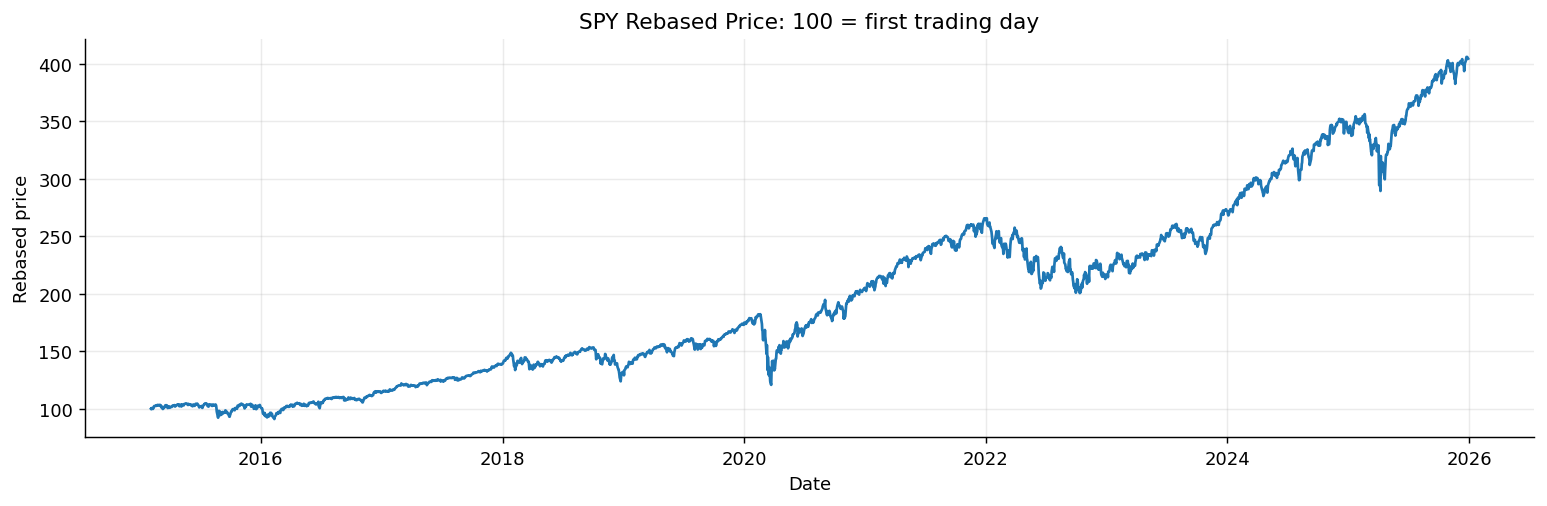

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
rebased = spy_returns["spy_close"] / spy_returns["spy_close"].iloc[0] * 100
ax.plot(rebased.index, rebased)
ax.set_title("SPY Rebased Price: 100 = first trading day")
ax.set_ylabel("Rebased price")
ax.set_xlabel("Date")
fig.tight_layout()
fig.savefig(FIGURES / "01_spy_rebased_price.png", bbox_inches="tight")
plt.show()

---
## 3. VIX — market uncertainty control

VIX is included as a market uncertainty control. It helps separate event effects from periods when the market was already stressed.

Saved output:

- `vix.parquet`

In [8]:
VIX_PATH = RAW / "vix.parquet"
FORCE_REFRESH_VIX = False  # set True to re-download from yfinance even if a cached file exists

vix = load_if_cached(VIX_PATH, force=FORCE_REFRESH_VIX)

if vix is not None:
    print(f"Loaded cached VIX from {VIX_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(vix):,} rows). Set FORCE_REFRESH_VIX = True to re-download.")
else:
    vix = yf.download(
        "^VIX",
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
    )

    vix = flatten_yfinance_columns(vix)
    vix = normalise_date_index(vix)
    vix = vix[["Close"]].rename(columns={"Close": "vix_close"})

    vix["vix_change"] = vix["vix_close"].diff()
    vix["vix_high_regime"] = (vix["vix_close"] >= 30).astype(int)

    save_table(vix, VIX_PATH)

    print(f"VIX rows       : {len(vix):,}")

print(f"Mean VIX       : {vix['vix_close'].mean():.2f}")
print(f"Max VIX        : {vix['vix_close'].max():.2f} on {vix['vix_close'].idxmax().date()}")
print(f"VIX >= 30 days : {int(vix['vix_high_regime'].sum()):,}")
vix.head()

Loaded cached VIX from data/raw/vix.parquet (2,765 rows). Set FORCE_REFRESH_VIX = True to re-download.
Mean VIX       : 18.33
Max VIX        : 82.69 on 2020-03-16
VIX >= 30 days : 156


,vix_close,vix_change,vix_high_regime
date,,,
2015-01-02,17.790001,NaN,0
2015-01-05,19.920000,2.129999,0
2015-01-06,21.120001,1.200001,0
2015-01-07,19.309999,-1.810001,0
2015-01-08,17.010000,-2.299999,0


## 4. Macroeconomic Indicators — FRED

This section collects the raw macroeconomic indicators used throughout the project from the Federal Reserve Economic Data (FRED) database.

The variables include:

- Federal Funds Effective Rate (`fed_funds_rate`)
- Consumer Price Index, level (`cpi`)
- Unemployment Rate (`unemployment`)
- 10-Year Treasury Yield (`treasury_10y`)
- 2-Year Treasury Yield (`treasury_2y`)
- 10Y–2Y Treasury Yield Spread, pre-computed (`yield_spread`)
- Manufacturing Employment (`mfg_employment`)

**Note (documentation correction, 2026-07-06):** the column names above match what is actually cached in `data/raw/macro_indicators.parquet` and frozen downstream in `master_dataset.parquet` / `05_data_dictionary.md` / `dataset_version.md`. An earlier version of this cell's markdown referenced `cpi_index`, `unemployment_rate`, and a `cpi_yoy` (year-on-year) series — `cpi_yoy` was never actually collected anywhere in the pipeline, and the other two names do not match the cached schema. This is a markdown-only correction (see `docs/research_bible/10_decision_log.md`, 2026-07-06 entry); no code in this notebook was changed, and the underlying cached data and all downstream frozen artefacts are unaffected.

These indicators are downloaded at their native reporting frequency (monthly or daily where applicable) and stored as raw datasets.

Monthly indicators are forward-filled to business-day frequency only during the dataset integration stage (Mission 03) so they can align with daily SPY trading data.

The collected data forms the macroeconomic component of the project's canonical dataset (`master_dataset.parquet`) but is **not** feature engineered in this notebook.

This notebook is the historical record of how `data/raw/macro_indicators.parquet` was originally collected; per `docs/research_bible/10_decision_log.md` (2026-07-06), the frozen `master_dataset.parquet` / `feature_matrix.parquet` and their contracts are the authoritative source for current column names and values, not this notebook's live code.

Output

data/raw/macro_indicators.parquet

In [9]:
FRED_SERIES = {
    "fed_funds_rate": "FEDFUNDS",
    "cpi_index": "CPIAUCSL",
    "unemployment_rate": "UNRATE",
    "treasury_10y": "GS10",
    "treasury_2y": "GS2",
}

MACRO_PATH = RAW / "macro_indicators.parquet"
FORCE_REFRESH_MACRO = False  # set True to re-pull from FRED even if a cached file exists

macro = load_if_cached(MACRO_PATH, force=FORCE_REFRESH_MACRO)

if macro is not None:
    print(f"Loaded cached macro indicators from {MACRO_PATH.relative_to(PROJECT_ROOT)} "
          f"({len(macro):,} rows). Set FORCE_REFRESH_MACRO = True to re-pull from FRED.")
else:
    fred_api_key = os.environ.get("FRED_API_KEY")
    if not fred_api_key:
        raise RuntimeError(
            "No cached macro_indicators.parquet found and FRED_API_KEY is not set. "
            "Set the FRED_API_KEY environment variable to fetch fresh data, or restore "
            "data/raw/macro_indicators.parquet from a previous run."
        )
    fred = Fred(api_key=fred_api_key)

    macro_frames = {}

    for clean_name, series_code in FRED_SERIES.items():
        try:
            series = fred.get_series(
                series_code,
                observation_start=START_DATE,
                observation_end=END_DATE,
            )

            series = series.dropna()
            series.name = clean_name
            macro_frames[clean_name] = series

            print(f"✓ {clean_name:<20} {series_code:<10} {len(series):>4} observations")

        except Exception as exc:
            print(f"✗ {clean_name:<20} {series_code:<10} failed: {exc}")

    macro = pd.DataFrame(macro_frames)
    macro.index = pd.to_datetime(macro.index)
    macro.index.name = "date"
    macro = macro.sort_index()

    if "cpi_index" in macro.columns:
        macro["cpi_yoy"] = macro["cpi_index"].pct_change(12) * 100

    if {"treasury_10y", "treasury_2y"}.issubset(macro.columns):
        macro["yield_spread_10y_2y"] = macro["treasury_10y"] - macro["treasury_2y"]

    save_table(macro, MACRO_PATH)
    print(f"\nMacro rows saved at native FRED frequency: {len(macro):,}")

macro.tail()

Loaded cached macro indicators from data/raw/macro_indicators.parquet (2,870 rows). Set FORCE_REFRESH_MACRO = True to re-pull from FRED.


,fed_funds_rate,cpi,unemployment,treasury_10y,treasury_2y,mfg_employment,yield_spread
date,,,,,,,
2025-12-25,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-26,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-29,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-30,3.72,326.031,4.4,4.14,3.5,12580.0,0.64
2025-12-31,3.72,326.031,4.4,4.14,3.5,12580.0,0.64


---
## 5. FOMC event calendar

Federal Reserve announcements are included as a clean macro-policy event source.

Saved output:

- `fomc_dates.parquet`

The `rate_decision` labels are simplified into `hike`, `cut`, `hold`, `taper`, and `emergency_cut`. More detailed basis-point changes can be added later if needed.

In [10]:
fomc_data = [
    # 2015
    ("2015-01-28", "hold"), ("2015-03-18", "hold"), ("2015-04-29", "hold"),
    ("2015-06-17", "hold"), ("2015-07-29", "hold"), ("2015-09-17", "hold"),
    ("2015-10-28", "hold"), ("2015-12-16", "hike"),
    # 2016
    ("2016-01-27", "hold"), ("2016-03-16", "hold"), ("2016-04-27", "hold"),
    ("2016-06-15", "hold"), ("2016-07-27", "hold"), ("2016-09-21", "hold"),
    ("2016-11-02", "hold"), ("2016-12-14", "hike"),
    # 2017
    ("2017-02-01", "hold"), ("2017-03-15", "hike"), ("2017-05-03", "hold"),
    ("2017-06-14", "hike"), ("2017-07-26", "hold"), ("2017-09-20", "hold"),
    ("2017-11-01", "hold"), ("2017-12-13", "hike"),
    # 2018
    ("2018-01-31", "hold"), ("2018-03-21", "hike"), ("2018-05-02", "hold"),
    ("2018-06-13", "hike"), ("2018-08-01", "hold"), ("2018-09-26", "hike"),
    ("2018-11-08", "hold"), ("2018-12-19", "hike"),
    # 2019
    ("2019-01-30", "hold"), ("2019-03-20", "hold"), ("2019-05-01", "hold"),
    ("2019-06-19", "hold"), ("2019-07-31", "cut"), ("2019-09-18", "cut"),
    ("2019-10-30", "cut"), ("2019-12-11", "hold"),
    # 2020
    ("2020-01-29", "hold"), ("2020-03-03", "emergency_cut"), ("2020-03-15", "emergency_cut"),
    ("2020-04-29", "hold"), ("2020-06-10", "hold"), ("2020-07-29", "hold"),
    ("2020-09-16", "hold"), ("2020-11-05", "hold"), ("2020-12-16", "hold"),
    # 2021
    ("2021-01-27", "hold"), ("2021-03-17", "hold"), ("2021-04-28", "hold"),
    ("2021-06-16", "hold"), ("2021-07-28", "hold"), ("2021-09-22", "hold"),
    ("2021-11-03", "hold"), ("2021-12-15", "taper"),
    # 2022
    ("2022-01-26", "hold"), ("2022-03-16", "hike"), ("2022-05-04", "hike"),
    ("2022-06-15", "hike"), ("2022-07-27", "hike"), ("2022-09-21", "hike"),
    ("2022-11-02", "hike"), ("2022-12-14", "hike"),
    # 2023
    ("2023-02-01", "hike"), ("2023-03-22", "hike"), ("2023-05-03", "hike"),
    ("2023-06-14", "hold"), ("2023-07-26", "hike"), ("2023-09-20", "hold"),
    ("2023-11-01", "hold"), ("2023-12-13", "hold"),
    # 2024
    ("2024-01-31", "hold"), ("2024-03-20", "hold"), ("2024-05-01", "hold"),
    ("2024-06-12", "hold"), ("2024-07-31", "hold"), ("2024-09-18", "cut"),
    ("2024-11-07", "cut"), ("2024-12-18", "cut"),
    # 2025 planned / placeholder labels to be verified before final submission
    ("2025-01-29", "hold"), ("2025-03-19", "hold"), ("2025-05-07", "hold"),
    ("2025-06-18", "hold"), ("2025-07-30", "hold"), ("2025-09-17", "hold"),
    ("2025-10-29", "hold"), ("2025-12-10", "hold"),
]

fomc_df = pd.DataFrame(fomc_data, columns=["date", "rate_decision"])
fomc_df["date"] = pd.to_datetime(fomc_df["date"])
fomc_df["event_type"] = "fomc"
fomc_df["is_emergency"] = (fomc_df["rate_decision"] == "emergency_cut").astype(int)
fomc_df["event_importance"] = np.where(fomc_df["rate_decision"].isin(["hike", "cut", "emergency_cut"]), 2, 1)

save_table(fomc_df, RAW / "fomc_dates.parquet", index=False)

print(f"FOMC events: {len(fomc_df)}")
print(fomc_df["rate_decision"].value_counts().to_string())
fomc_df.head()

FOMC events: 89
rate_decision
hold             60
hike             20
cut               6
emergency_cut     2
taper             1


,date,rate_decision,event_type,is_emergency,event_importance
0,2015-01-28,hold,fomc,0,1
1,2015-03-18,hold,fomc,0,1
2,2015-04-29,hold,fomc,0,1
3,2015-06-17,hold,fomc,0,1
4,2015-07-29,hold,fomc,0,1


---
## 6. Presidential communications — American Presidency Project

This section loads manually downloaded CSV files from the American Presidency Project.

### Manual download instructions

1. Go to the American Presidency Project advanced search page.
2. Set the date range to **01/01/2015–12/31/2025**.
3. Download one CSV per document category.
4. Save the files into:

```text
data/raw/app_csv/
```

Recommended categories for the narrowed dissertation:

- Executive Orders
- Press Conferences
- Spoken Addresses and Remarks
- Statements by the President

Proclamations and signing statements can be added later, but the first four categories are enough for the main project.

Saved output:

- `app_presidential_documents_raw.parquet`
- `app_presidential_documents_economic.parquet`

In [11]:
APP_CSV_DIR = RAW / "app_csv"
APP_CSV_DIR.mkdir(parents=True, exist_ok=True)

ECONOMIC_KEYWORDS = [
    "economy", "economic", "jobs", "employment", "unemployment", "inflation",
    "interest rate", "federal reserve", "fed", "market", "stock", "wall street",
    "trade", "tariff", "tax", "budget", "debt", "deficit", "spending",
    "infrastructure", "manufacturing", "energy", "oil", "gas", "sanctions",
    "china", "supply chain", "regulation", "bank", "financial", "stimulus",
]


def clean_app_columns(df: pd.DataFrame, source_file: str) -> pd.DataFrame:
    'Standardise APP CSV columns as far as possible.'
    df = df.copy()
    original_columns = list(df.columns)
    df.columns = [str(c).strip().lower().replace(" ", "_").replace("/", "_") for c in df.columns]

    # Flexible column mapping because APP CSV exports can vary by category.
    possible_date_cols = ["date", "doc_date", "publication_date"]
    possible_title_cols = ["title", "document_title", "name"]
    possible_url_cols = ["url", "link", "document_url"]
    possible_president_cols = ["president", "person", "speaker"]

    def first_existing(possible_cols):
        return next((c for c in possible_cols if c in df.columns), None)

    date_col = first_existing(possible_date_cols)
    title_col = first_existing(possible_title_cols)
    url_col = first_existing(possible_url_cols)
    president_col = first_existing(possible_president_cols)

    out = pd.DataFrame()
    out["date"] = pd.to_datetime(df[date_col], errors="coerce") if date_col else pd.NaT
    out["title"] = df[title_col].astype(str) if title_col else ""
    out["url"] = df[url_col].astype(str) if url_col else ""
    out["president"] = df[president_col].astype(str) if president_col else "unknown"
    out["doc_type"] = Path(source_file).stem.lower().replace(" ", "_").replace("-", "_")
    out["source_file"] = source_file

    # Preserve any text/body column if already present in the CSV.
    text_candidates = [c for c in df.columns if c in ["text", "full_text", "body", "transcript", "content"]]
    out["text"] = df[text_candidates[0]].astype(str) if text_candidates else ""

    out = out.dropna(subset=["date"])
    out = out[(out["date"] >= START_DATE) & (out["date"] <= END_DATE)]
    out = out.drop_duplicates(subset=["date", "title", "url"])

    if out.empty:
        print(f"Warning: {source_file} loaded but no rows survived cleaning. Original columns: {original_columns}")

    return out


app_frames = []
for csv_file in sorted(APP_CSV_DIR.glob("*.csv")):
    try:
        raw_csv = pd.read_csv(csv_file)
        cleaned = clean_app_columns(raw_csv, csv_file.name)
        app_frames.append(cleaned)
        print(f"✓ {csv_file.name:<45} {len(cleaned):>5} rows")
    except Exception as exc:
        print(f"✗ {csv_file.name:<45} failed: {exc}")

if app_frames:
    app_docs_raw = pd.concat(app_frames, ignore_index=True).sort_values("date")
    save_table(app_docs_raw, RAW / "app_presidential_documents_raw.parquet", index=False)
else:
    app_docs_raw = pd.DataFrame(columns=["date", "title", "url", "president", "doc_type", "source_file", "text"])
    print("No APP CSV files found yet. Add CSV files to data/raw/app_csv/ and re-run this cell.")

print(f"\nTotal APP raw documents: {len(app_docs_raw):,}")
app_docs_raw.head()

✓ executive_orders_01.csv                         100 rows
✓ executive_orders_02.csv                         100 rows
✓ executive_orders_03.csv                         100 rows
✓ executive_orders_04.csv                         100 rows
✓ executive_orders_05.csv                         100 rows
✓ executive_orders_06.csv                         100 rows
✓ executive_orders_07.csv                          85 rows
✓ executive_orders_08.csv                           0 rows
✓ press_conferences_01.csv                        100 rows
✓ press_conferences_02.csv                        100 rows
✓ press_conferences_03.csv                        100 rows
✓ press_conferences_04.csv                        100 rows
✓ press_conferences_05.csv                        100 rows
✓ press_conferences_06.csv                        100 rows
✓ press_conferences_07.csv                        100 rows
✓ press_conferences_08.csv                         12 rows
✓ press_conferences_09.csv                        100 ro

,date,title,url,president,doc_type,source_file,text
8876,2015-01-01,Statement on the Death of Mario M. Cuomo,https://www.presidency.ucsb.edu/documents/stat...,Barack Obama,statements_01,statements_01.csv,
0,2015-01-02,Executive Order 13687—Imposing Additional Sanc...,https://www.presidency.ucsb.edu/documents/exec...,Barack Obama,executive_orders_01,executive_orders_01.csv,
8877,2015-01-03,Statement on the Death of Former Senator Edwar...,https://www.presidency.ucsb.edu/documents/stat...,Barack Obama,statements_01,statements_01.csv,
8878,2015-01-04,Statement on the Death of Stuart O. Scott,https://www.presidency.ucsb.edu/documents/stat...,Barack Obama,statements_01,statements_01.csv,
685,2015-01-05,Press Briefing by Press Secretary Josh Earnest,https://www.presidency.ucsb.edu/documents/pres...,Barack Obama,press_conferences_01,press_conferences_01.csv,


In [12]:
# ── Narrow APP documents to economically relevant communications ────────────
if not app_docs_raw.empty:
    searchable_text = (
        app_docs_raw["title"].fillna("") + " " +
        app_docs_raw["text"].fillna("") + " " +
        app_docs_raw["doc_type"].fillna("")
    ).str.lower()

    keyword_pattern = "|".join([k.replace(" ", r"\s+") for k in ECONOMIC_KEYWORDS])
    app_docs_economic = app_docs_raw[searchable_text.str.contains(keyword_pattern, regex=True, na=False)].copy()

    # If a CSV has no full text, keyword filtering mainly uses title and doc_type.
    app_docs_economic["event_type"] = "presidential_communication"
    app_docs_economic["has_full_text"] = app_docs_economic["text"].fillna("").str.len() > 100

    save_table(app_docs_economic, RAW / "app_presidential_documents_economic.parquet", index=False)

    print(f"Raw APP documents       : {len(app_docs_raw):,}")
    print(f"Economic APP documents  : {len(app_docs_economic):,}")
    print("\nDocuments by type:")
    print(app_docs_economic["doc_type"].value_counts().to_string())
else:
    app_docs_economic = app_docs_raw.copy()
    print("APP document table is empty. Nothing to filter yet.")

app_docs_economic.head()

Raw APP documents       : 10,892
Economic APP documents  : 1,208

Documents by type:
doc_type
executive_orders_02      37
executive_orders_04      34
executive_orders_01      33
statements_22            32
executive_orders_06      30
executive_orders_07      30
executive_orders_05      26
executive_orders_03      25
statements_11            23
spoken_addresses_30      22
spoken_addresses_29      21
statements_21            21
statements_10            20
spoken_addresses_14      19
spoken_addresses_39      19
spoken_addresses_31      18
spoken_addresses_34      18
statements_13            18
statements_18            18
statements_19            18
statements_09            17
spoken_addresses_32      16
statements_12            16
statements_14            16
spoken_addresses_28      15
press_conferences_13     15
signing_statements_01    14
spoken_addresses_37      14
statements_17            14
statements_05            13
spoken_addresses_27      13
spoken_addresses_38      13
statements

,date,title,url,president,doc_type,source_file,text,event_type,has_full_text
0,2015-01-02,Executive Order 13687—Imposing Additional Sanc...,https://www.presidency.ucsb.edu/documents/exec...,Barack Obama,executive_orders_01,executive_orders_01.csv,,presidential_communication,False
8879,2015-01-06,Joint Statement - United States-Mexico High-Le...,https://www.presidency.ucsb.edu/documents/join...,Barack Obama,statements_01,statements_01.csv,,presidential_communication,False
4418,2015-01-09,"Remarks at the Techmer PM, LLC, Manufacturing ...",https://www.presidency.ucsb.edu/documents/rema...,Barack Obama,spoken_addresses_01,spoken_addresses_01.csv,,presidential_communication,False
4420,2015-01-12,Remarks at the Federal Trade Commission Consti...,https://www.presidency.ucsb.edu/documents/rema...,Barack Obama,spoken_addresses_01,spoken_addresses_01.csv,,presidential_communication,False
2678,2015-01-16,"Proclamation 9228—Martin Luther King, Jr., Fed...",https://www.presidency.ucsb.edu/documents/proc...,Barack Obama,proclamations_01,proclamations_01.csv,,presidential_communication,False


---
## 7. Build a first modelling calendar

This creates a first daily dataset that later notebooks can use for exploratory analysis, event windows, feature engineering, and prediction.

This is not the final modelling table. It is a clean checkpoint showing that all main data sources can be aligned by date.

Saved output:

- `daily_modelling_calendar_v1.parquet`

In [24]:
calendar = spy_returns.copy()
calendar = calendar.join(vix, how="left")

# Use the loaded macro dataframe, regardless of whether the earlier cell named it
# macro_daily or macro.
if "macro_daily" in globals():
    macro_for_calendar = macro_daily.copy()
elif "macro" in globals():
    macro_for_calendar = macro.copy()
else:
    macro_for_calendar = pd.read_parquet(RAW / "macro_indicators.parquet")

# Ensure datetime index for joining to trading-day calendar
if "date" in macro_for_calendar.columns:
    macro_for_calendar["date"] = pd.to_datetime(macro_for_calendar["date"])
    macro_for_calendar = macro_for_calendar.set_index("date")

macro_for_calendar.index = pd.to_datetime(macro_for_calendar.index)
macro_for_calendar = macro_for_calendar.sort_index()

calendar = calendar.join(macro_for_calendar, how="left")

# FOMC event flag on trading dates. If a meeting falls on a non-trading day,
# later notebooks can shift it to the next trading day during event-window construction.
fomc_flags = fomc_df.set_index("date")[["rate_decision", "is_emergency", "event_importance"]]
fomc_flags = fomc_flags.rename(columns={"event_importance": "fomc_importance"})
calendar = calendar.join(fomc_flags, how="left")
calendar["is_fomc_day"] = calendar["rate_decision"].notna().astype(int)
calendar["is_fomc_emergency"] = calendar["is_emergency"].fillna(0).astype(int)
calendar["fomc_importance"] = calendar["fomc_importance"].fillna(0).astype(int)
calendar = calendar.drop(columns=["is_emergency"])

# Presidential communication count by trading date.
# For simplicity here, same-day communications are counted on calendar dates.
# Later notebooks can decide whether after-market communications move to next trading day.
if not app_docs_economic.empty:
    app_daily = app_docs_economic.groupby("date").agg(
        presidential_event_count=("title", "count"),
        presidential_full_text_count=("has_full_text", "sum"),
    )
    calendar = calendar.join(app_daily, how="left")
else:
    calendar["presidential_event_count"] = 0
    calendar["presidential_full_text_count"] = 0

calendar["presidential_event_count"] = calendar["presidential_event_count"].fillna(0).astype(int)
calendar["presidential_full_text_count"] = calendar["presidential_full_text_count"].fillna(0).astype(int)
calendar["is_presidential_event_day"] = (calendar["presidential_event_count"] > 0).astype(int)
calendar["is_any_event_day"] = ((calendar["is_fomc_day"] == 1) | (calendar["is_presidential_event_day"] == 1)).astype(int)

save_table(calendar, RAW / "daily_modelling_calendar_v1.parquet")

print(f"Calendar rows: {len(calendar):,}")
print(f"Columns      : {len(calendar.columns)}")
calendar.head()

Calendar rows: 2,743
Columns      : 28


,spy_close,spy_log_return,spy_simple_return,spy_return_direction,target_next_day_log_return,target_next_day_direction,lag1_return,rolling_5d_return,rolling_21d_return,rolling_21d_volatility,...,mfg_employment,yield_spread,rate_decision,fomc_importance,is_fomc_day,is_fomc_emergency,presidential_event_count,presidential_full_text_count,is_presidential_event_day,is_any_event_day
date,,,,,,,,,,,,,,,,,,,,,
2015-02-03,169.200500,0.014357,0.014461,1,-0.003815,0,0.012308,0.010305,-0.002876,0.178846,...,12265.0,1.33,NaN,0,0,0,0,0,0,0
2015-02-04,168.556198,-0.003815,-0.003808,0,0.010045,1,0.014357,0.019397,0.011533,0.167061,...,12265.0,1.33,NaN,0,0,0,0,0,0,0
2015-02-05,170.257797,0.010045,0.010095,1,-0.002769,0,-0.003815,0.020240,0.031041,0.165994,...,12265.0,1.33,NaN,0,0,0,0,0,0,0
2015-02-06,169.786987,-0.002769,-0.002765,0,-0.004486,0,0.010045,0.030126,0.015888,0.161694,...,12265.0,1.33,NaN,0,0,0,0,0,0,0
2015-02-09,169.027039,-0.004486,-0.004476,0,0.010597,1,-0.002769,0.013332,-0.006187,0.150428,...,12265.0,1.33,NaN,0,0,0,0,0,0,0


**Implementation note:** This checkpoint uses the cached macro indicators from `macro_indicators.parquet`. Earlier versions of the notebook used the variable name `macro_daily`; the current version standardises the macro table before joining it to the trading-day calendar.

---
## 8. Data quality checks

These checks are intentionally simple. Their purpose is to catch obvious collection problems before moving to the EDA notebook.

In [28]:
# Standardise macro reference for quality report
if "macro_daily" in globals():
    macro_for_quality = macro_daily.copy()
elif "macro_for_calendar" in globals():
    macro_for_quality = macro_for_calendar.copy()
elif "macro" in globals():
    macro_for_quality = macro.copy()
else:
    macro_for_quality = pd.read_parquet(RAW / "macro_indicators.parquet")

if "date" in macro_for_quality.columns:
    macro_for_quality["date"] = pd.to_datetime(macro_for_quality["date"])
    macro_for_quality = macro_for_quality.set_index("date")

macro_for_quality.index = pd.to_datetime(macro_for_quality.index)
macro_for_quality = macro_for_quality.sort_index()

quality_rows = []

def add_quality_row(dataset, rows, start, end, missing, notes=""):
    quality_rows.append({
        "dataset": dataset,
        "rows": rows,
        "start_date": start,
        "end_date": end,
        "missing_values": missing,
        "notes": notes,
    })

add_quality_row(
    "SPY OHLCV",
    len(spy_ohlcv),
    spy_ohlcv.index.min().date(),
    spy_ohlcv.index.max().date(),
    int(spy_ohlcv.isna().sum().sum()),
    "Main S&P 500 proxy",
)

add_quality_row(
    "SPY returns",
    len(spy_returns),
    spy_returns.index.min().date(),
    spy_returns.index.max().date(),
    int(spy_returns.isna().sum().sum()),
    "Includes next-day target variables",
)

add_quality_row(
    "VIX",
    len(vix),
    vix.index.min().date(),
    vix.index.max().date(),
    int(vix.isna().sum().sum()),
    "Market uncertainty control",
)

add_quality_row(
    "Macro indicators",
    len(macro_for_quality),
    macro_for_quality.index.min().date(),
    macro_for_quality.index.max().date(),
    int(macro_for_quality.isna().sum().sum()),
    "Macro indicators aligned to business-day frequency",
)

add_quality_row(
    "FOMC events",
    len(fomc_df),
    fomc_df["date"].min().date(),
    fomc_df["date"].max().date(),
    int(fomc_df.isna().sum().sum()),
    "Policy announcement calendar",
)

if not app_docs_economic.empty:
    add_quality_row(
        "APP economic documents",
        len(app_docs_economic),
        app_docs_economic["date"].min().date(),
        app_docs_economic["date"].max().date(),
        int(app_docs_economic.isna().sum().sum()),
        "Filtered presidential communications",
    )
else:
    add_quality_row(
        "APP economic documents",
        0,
        None,
        None,
        0,
        "No APP CSVs loaded yet",
    )

quality_report = pd.DataFrame(quality_rows)
save_table(quality_report, RAW / "data_quality_report.parquet", index=False)
quality_report

,dataset,rows,start_date,end_date,missing_values,notes
0,SPY OHLCV,2765,2015-01-02,2025-12-30,0,Main S&P 500 proxy
1,SPY returns,2743,2015-02-03,2025-12-29,0,Includes next-day target variables
2,VIX,2765,2015-01-02,2025-12-30,1,Market uncertainty control
3,Macro indicators,2870,2015-01-01,2025-12-31,0,Macro indicators aligned to business-day frequ...
4,FOMC events,89,2015-01-28,2025-12-10,0,Policy announcement calendar
5,APP economic documents,1208,2015-01-02,2025-12-19,0,Filtered presidential communications


In [29]:
# ── Saved file inventory ────────────────────────────────────────────────────
print("Saved files in data/raw:")
for path in sorted(RAW.glob("*")):
    if path.is_file():
        print(f"{path.name:<50} {path.stat().st_size / 1024:>9.1f} KB")

Saved files in data/raw:
.DS_Store                                               10.0 KB
.gitkeep                                                 0.0 KB
README.md                                                0.9 KB
app_presidential_documents.parquet                     799.6 KB
app_presidential_documents_economic.parquet            101.1 KB
app_presidential_documents_raw.parquet                 696.5 KB
daily_modelling_calendar_v1.parquet                    267.2 KB
data_quality_report.parquet                              4.3 KB
fomc_dates.parquet                                       4.3 KB
gdelt_sample.parquet                                    40.4 KB
macro_indicators.parquet                                33.4 KB
prices.parquet                                          99.0 KB
spy_ohlcv.parquet                                      139.2 KB
spy_returns.parquet                                    226.0 KB
vix.parquet                                             45.1 KB


---
## 9. Collection summary and next notebook

The narrowed data collection phase is now focused enough for a strong MSc dissertation.

### Main outputs

| File | Role in project |
|---|---|
| `spy_ohlcv.parquet` | Raw SPY market data. |
| `spy_returns.parquet` | Return features and next-day prediction targets. |
| `vix.parquet` | Market uncertainty control. |
| `macro_indicators.parquet` | Macro controls. |
| `fomc_dates.parquet` | Macro-policy event calendar. |
| `app_presidential_documents_raw.parquet` | Raw presidential communication metadata/text where available. |
| `app_presidential_documents_economic.parquet` | Narrowed economic/policy communication events. |
| `daily_modelling_calendar_v1.parquet` | First aligned daily modelling table. |
| `data_quality_report.parquet` | Collection quality report. |

### Recommended next notebook

`02_eda_event_windows.ipynb`

Suggested next tasks:

1. Inspect return distribution and volatility regimes.
2. Create event windows around FOMC and presidential communication dates.
3. Estimate abnormal returns using a market-adjusted or mean-adjusted benchmark.
4. Build the final feature table for machine learning.